# DATA QUALITY ISSUE - ROOT CAUSE ANALYSIS

## 1. Introduction

In this notebook, I analyze a **data quality issue** in a car pricing dataset from the [Kaggle Playground Series S4E9](https://www.kaggle.com/competitions/playground-series-s4e9). During exploratory analysis, I observed that cars priced above **1 million** are concentrated in **a few fixed price levels**, with **no visible variation**.  
<br>





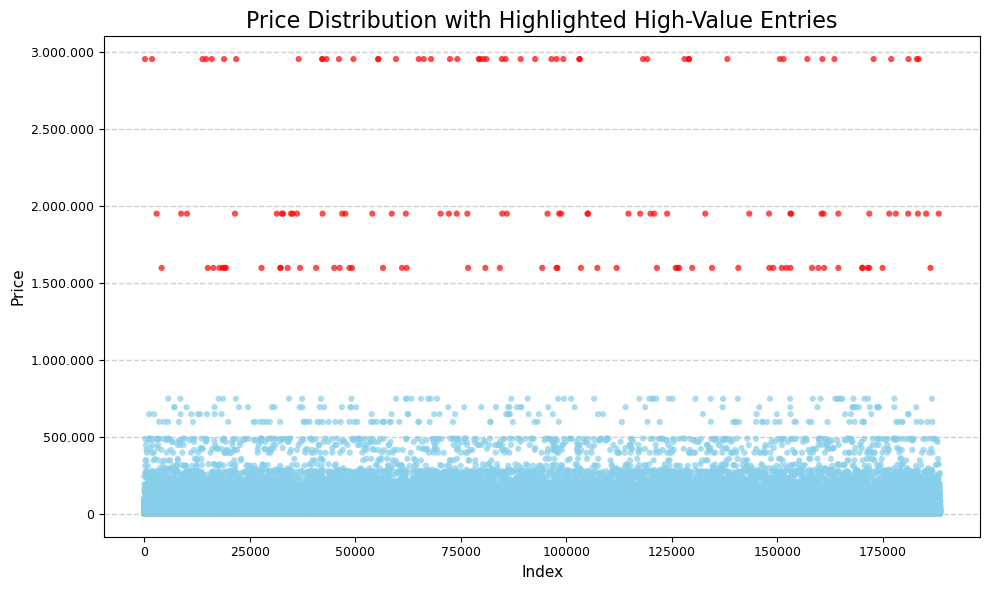

This pattern is unusual, as prices in this range are typically expected to vary depending on vehicle characteristics such as brand, model, year, and mileage.

The goal of this analysis is to determine whether this pattern reflects:
- a real market segment, or  
- a potential data quality issue  

and to identify the most likely cause using a structured, hypothesis-driven approach.

Issues like this are common in real-world datasets, especially in **pricing and sales data**, where errors can be introduced during data entry, transformation, or integration. In a Kaggle competition, understanding this pattern would make a difference.

**Do these values represent real market behavior or are they the result of a data issue?**

To answer this, the following explanations will be tested:

- **Manual or bulk data entry error**  
- **Placeholder values or price binning**  
- **Scaling error (unit mismatch)**  
- **Merge or lookup error during data integration**  
- **Real premium market segment**  
- **Synthetic data artifact**

#### Why this is important?

Because it improves data quality, helps prevent similar issues from hapenning agaiin and can lead to better model decisions.

## 2. Import Libraries & Load Data

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

warnings.simplefilter("ignore")

colors = ["#B0C4DE", "#87CEEB", "#1E90FF", "#4682B4"]

TITLE_FONTSIZE = 16
AXIS_LABEL_FONTSIZE = 11
TICK_FONTSIZE = 9
LEGEND_FONTSIZE = 9
LINEWIDTH_GRID = 1

df = pd.read_csv("train.csv")

print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (188533, 13)


## 3. Hypothesis Testing

### 3.1. Manual Data Entry or Bulk Overwrite Error

#### Hypothesis

The prices may have been modified through manual interaction with the dataset.

This could include human errors like:
- individual manual entry errors  
- or a **bulk overwrite action**, where multiple rows were filtered and assigned the same value (for example, through copy-paste or spreadsheet operations)

In both cases, the source of the issue would be **human-driven input** rather than a system-level transformation.

#### Expected Pattern

If this hypothesis is true, we would expect:

- **Small variations in values** due to typing differences  
- Slight inconsistencies (e.g., 1.600.000 vs 1.660.000 or 1.600.000 vs 1.060.000)  
- A **noisy or continuous distribution** of prices  

Even in the case of a bulk overwrite, we would typically expect:
- one dominant value, not multiple fixed levels  
- or values tied to a specific subset of similar records  

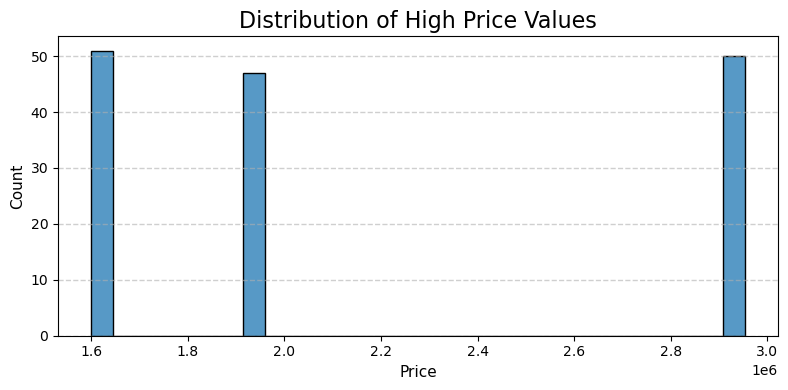

In [2]:
high_df = df[df["price"] > 1_000_000]
high_df["price"].value_counts()
plt.figure(figsize=(8,4))

sns.histplot(high_df["price"], bins=30)

plt.title("Distribution of High Price Values", fontsize=TITLE_FONTSIZE)
plt.xlabel("Price", fontsize=AXIS_LABEL_FONTSIZE)
plt.ylabel("Count", fontsize=AXIS_LABEL_FONTSIZE)

plt.grid(axis="y", linestyle="--", linewidth=LINEWIDTH_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

#### Observed Pattern

* "1.599.000" used 51 times.
* "2.954.083" used 50 times.
* "1.950.995" used 47 times.
* No other values is presented above "1.000.000".

We can confidently conclude that the data can be divided into three distinct groups. Let's plot these groups to visualize them together in one consolidated view.

- Only **three exact price values** appear above 1,000,000  
- These values are repeated many times with **no variation**  
- Each value is assigned to a **wide range of unrelated vehicles**

### 3.2. Placeholder Values vs Price Binning

#### Hypothesis

The fixed high-price values may be the result of:

- **Placeholder values**, used when the real price is missing or unknown  
- or **price binning**, where continuous values are grouped into predefined levels  

These are both systematic processes, but they represent different data issues.


#### Expected Pattern

If these values are **placeholders**, we would expect:

- A small number of repeated values  
- Values that do not depend on vehicle features  
- Possibly one dominant value, or a few arbitrary constants  

If these values are the result of **binning**, we would expect:

- A limited number of discrete price levels  
- Values that represent ranges (e.g., high-end categories)  
- Some relationship between price levels and vehicle characteristics  

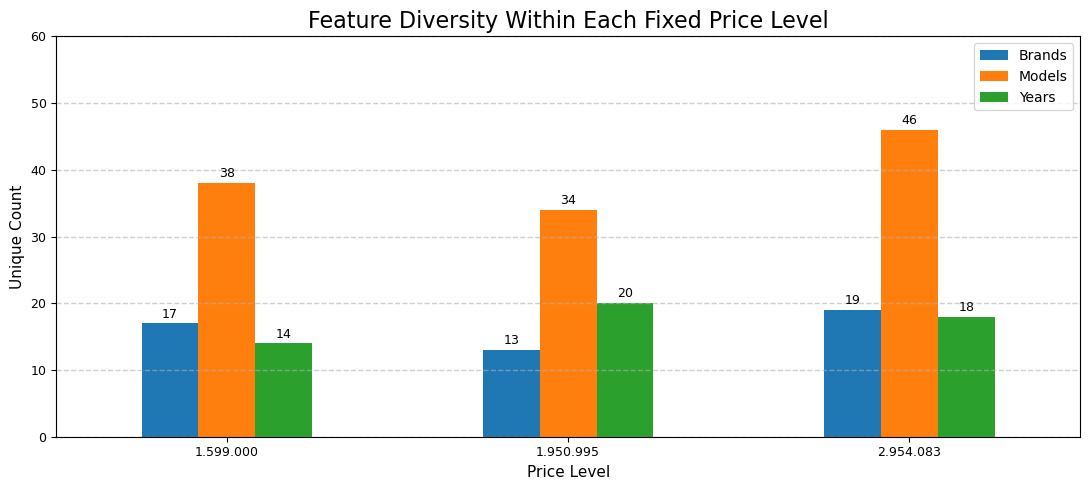

In [3]:
feature_diversity = (
    high_df
    .groupby("price")
    .agg(
        Brands=("brand", "nunique"),
        Models=("model", "nunique"),
        Years=("model_year", "nunique")
    )
    .reset_index()
)

feature_diversity["price_label"] = feature_diversity["price"].apply(lambda x: f"{x:,}".replace(",", "."))
feature_diversity = feature_diversity.drop(columns="price").set_index("price_label")

ax = feature_diversity.plot(
    kind="bar",
    figsize=(11,5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.title("Feature Diversity Within Each Fixed Price Level", fontsize=TITLE_FONTSIZE)
plt.xlabel("Price Level", fontsize=AXIS_LABEL_FONTSIZE)
plt.ylabel("Unique Count", fontsize=AXIS_LABEL_FONTSIZE)

plt.ylim(0, 60)

plt.xticks(rotation=0, fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

plt.grid(axis="y", linestyle="--", linewidth=LINEWIDTH_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

#### Observed Pattern

Each fixed price level contains a diverse set of vehicles:

- **1,599,000** includes 17 brands, 38 models, and 14 model years  
- **1,950,995** includes 13 brands, 34 models, and 20 model years  
- **2,954,083** includes 19 brands, 46 models, and 18 model years  

This means the fixed prices are not tied to a narrow vehicle profile.

If these were meaningful price bins, we would expect each level to represent a more consistent group of cars. Instead, each price level contains many different brands, models, and years.

#### Evaluation

The chart supports the **placeholder or generic assignment** explanation more than a meaningful price binning explanation.

The fixed prices are assigned across many different vehicle types, rather than reflecting clear high-end market categories.

This suggests that the values were likely introduced by a systematic process, but they do not behave like well-defined pricing bins.

### 3.3. Merge or Lookup Error

#### Hypothesis

The price values may have been assigned incorrectly during a data merge or lookup process.

This can happen when:
- records are joined using an incorrect key  
- multiple vehicles are matched to the same price  
- a lookup table contains only a limited number of price values  

In this case, the issue would come from a **data integration error**, not from the original price values.

#### Expected Pattern

If this hypothesis is true, we would expect:

- The same price value assigned to **many different vehicles**  
- No strong relationship between price and key features  
- Price behaving **independently** from brand, model, or year  

In [4]:
diversity_check = (
    high_df
    .groupby("price")
    .agg(
        Total_Cars=("price", "size"),
        Unique_Brands=("brand", "nunique"),
        Unique_Models=("model", "nunique"),
        Unique_Years=("model_year", "nunique")
    )
    .reset_index()
)

diversity_check["price_label"] = diversity_check["price"].apply(lambda x: f"{x:,}".replace(",", "."))
diversity_check = diversity_check.drop(columns="price")

display(diversity_check)

,Total_Cars,Unique_Brands,Unique_Models,Unique_Years,price_label
0,51,17,38,14,1.599.000
1,47,13,34,20,1.950.995
2,50,19,46,18,2.954.083


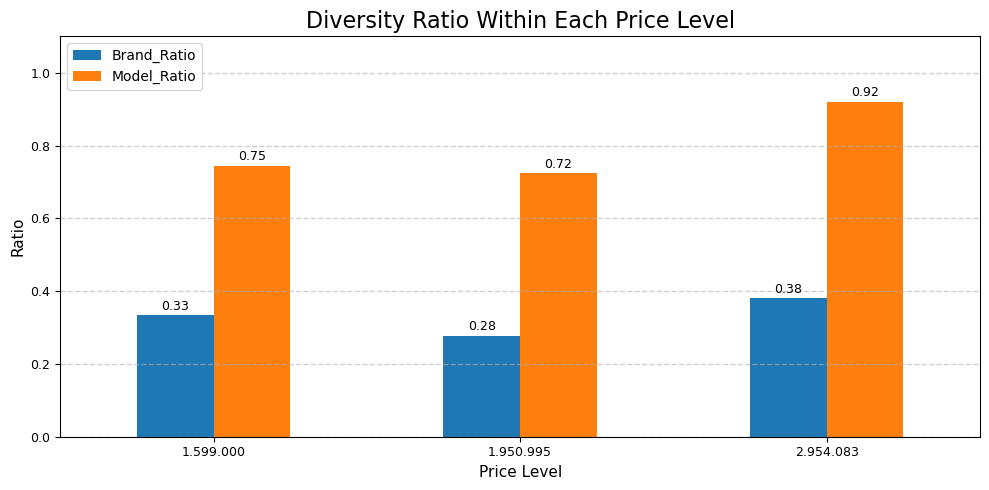

In [5]:
ratio_df = diversity_check.copy()

ratio_df["Brand_Ratio"] = ratio_df["Unique_Brands"] / ratio_df["Total_Cars"]
ratio_df["Model_Ratio"] = ratio_df["Unique_Models"] / ratio_df["Total_Cars"]

ratio_df = ratio_df.set_index("price_label")

ax = ratio_df[["Brand_Ratio", "Model_Ratio"]].plot(
    kind="bar",
    figsize=(10,5)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9, padding=2)

plt.title("Diversity Ratio Within Each Price Level", fontsize=TITLE_FONTSIZE)
plt.xlabel("Price Level", fontsize=AXIS_LABEL_FONTSIZE)
plt.ylabel("Ratio", fontsize=AXIS_LABEL_FONTSIZE)

plt.ylim(0, 1.1)

plt.xticks(rotation=0, fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

plt.grid(axis="y", linestyle="--", linewidth=LINEWIDTH_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

#### Observed Pattern

Each fixed price level includes a highly diverse set of vehicles.

- Model diversity is extremely high, reaching up to **92%**, meaning most cars within a price level are different models  
- Brand diversity is also significant, ranging between **28% and 38%**  

This shows that the same price values are assigned across a wide variety of unrelated vehicles.

### Evaluation

This pattern strongly supports the merge or lookup error hypothesis.

In a valid dataset, price is expected to vary significantly across different models and brands. However, here we observe the opposite: a small number of fixed price values assigned to a large and diverse set of vehicles.

The very high model diversity within each price level indicates that these prices are not derived from vehicle characteristics.

Instead, this behavior is consistent with a data integration issue, where price values may have been incorrectly mapped or joined during preprocessing.

### 3.4. Real Premium Segment

#### Hypothesis

The high-price values may represent a real premium segment of the market.

In this case, these vehicles would be genuinely expensive, and the observed pattern would reflect real-world pricing.

#### Expected Pattern

If this hypothesis is true, we would expect:

- Prices to vary even within the premium segment  
- A consistent relationship between price and vehicle characteristics  
- Similar vehicles to have similar prices, with natural variation  

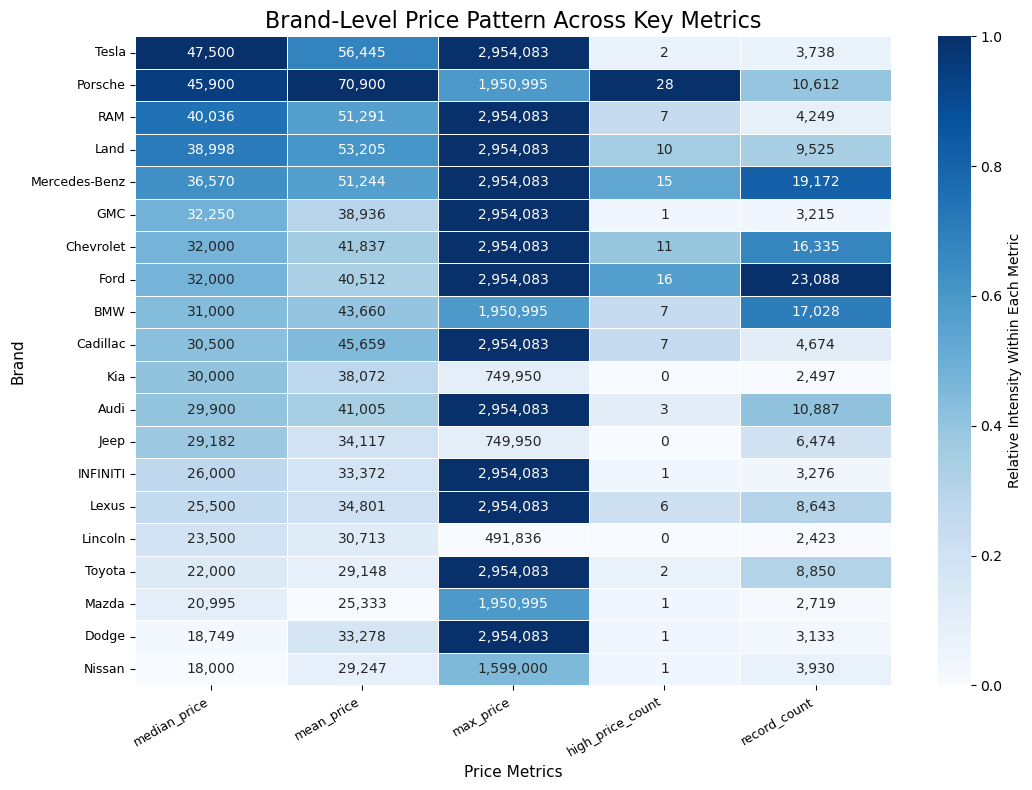

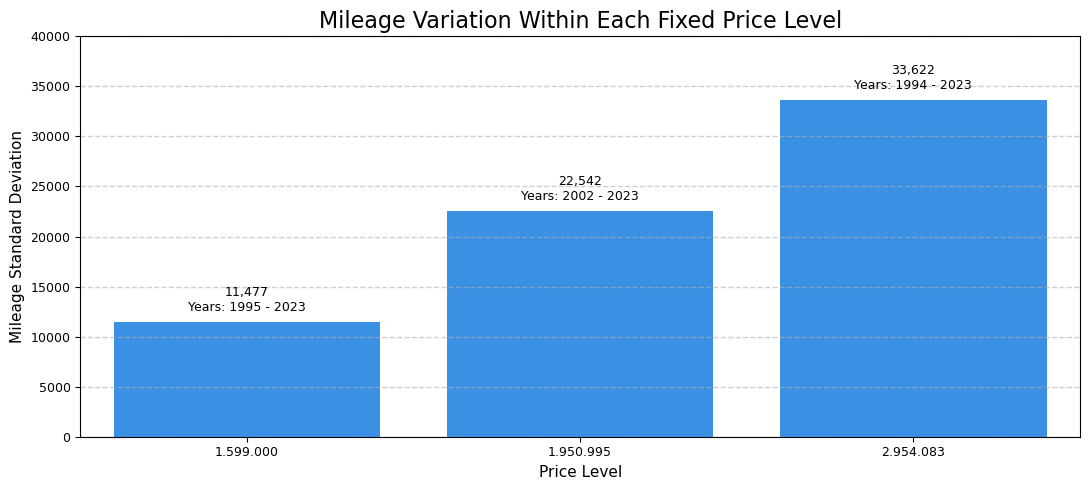

In [6]:
top_brands = (
    df["brand"]
    .value_counts()
    .head(20)
    .index
)

brand_price_summary = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")
    .agg(
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        max_price=("price", "max"),
        high_price_count=("price", lambda x: (x > 1_000_000).sum()),
        record_count=("price", "size")
    )
    .sort_values("median_price", ascending=False)
)

heatmap_data = brand_price_summary[
    ["median_price", "mean_price", "max_price", "high_price_count", "record_count"]
]

heatmap_scaled = heatmap_data.copy()

for col in heatmap_scaled.columns:
    col_min = heatmap_scaled[col].min()
    col_max = heatmap_scaled[col].max()
    heatmap_scaled[col] = (heatmap_scaled[col] - col_min) / (col_max - col_min)

annot_data = heatmap_data.copy()
annot_data["median_price"] = annot_data["median_price"].map("{:,.0f}".format)
annot_data["mean_price"] = annot_data["mean_price"].map("{:,.0f}".format)
annot_data["max_price"] = annot_data["max_price"].map("{:,.0f}".format)
annot_data["high_price_count"] = annot_data["high_price_count"].map("{:,.0f}".format)
annot_data["record_count"] = annot_data["record_count"].map("{:,.0f}".format)

plt.figure(figsize=(11, 8))

sns.heatmap(
    heatmap_scaled,
    annot=annot_data,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Relative Intensity Within Each Metric"}
)

plt.title("Brand-Level Price Pattern Across Key Metrics", fontsize=TITLE_FONTSIZE)
plt.xlabel("Price Metrics", fontsize=AXIS_LABEL_FONTSIZE)
plt.ylabel("Brand", fontsize=AXIS_LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE, rotation=30, ha="right")
plt.yticks(fontsize=TICK_FONTSIZE)
plt.tight_layout()
plt.show()

variation_check = (
    high_df
    .groupby("price")
    .agg(
        Mileage_Std=("milage", "std"),
        Min_Year=("model_year", "min"),
        Max_Year=("model_year", "max")
    )
    .reset_index()
)

variation_check["price_label"] = variation_check["price"].apply(lambda x: f"{x:,}".replace(",", "."))
variation_check["year_range"] = variation_check["Min_Year"].astype(str) + " - " + variation_check["Max_Year"].astype(str)

plt.figure(figsize=(11,5))

ax = sns.barplot(
    data=variation_check,
    x="price_label",
    y="Mileage_Std",
    color=colors[2]
)

for i, row in variation_check.iterrows():
    ax.text(
        i,
        row["Mileage_Std"] + 800,
        f'{row["Mileage_Std"]:,.0f}\nYears: {row["year_range"]}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Mileage Variation Within Each Fixed Price Level", fontsize=TITLE_FONTSIZE)
plt.xlabel("Price Level", fontsize=AXIS_LABEL_FONTSIZE)
plt.ylabel("Mileage Standard Deviation", fontsize=AXIS_LABEL_FONTSIZE)

plt.ylim(0, 40000)

plt.xticks(rotation=0, fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)

plt.grid(axis="y", linestyle="--", linewidth=LINEWIDTH_GRID, alpha=0.6)

plt.tight_layout()
plt.show()

#### Observed Pattern

Within each price level, there is **no variation in price**, while other key features vary significantly:

- Price standard deviation is **zero** across all groups  
- Mileage shows substantial variation (up to ~33,000)  
- Model year also varies across multiple years  

This means that vehicles with different ages and usage levels are assigned exactly the same price.

#### Evaluation

This pattern is not consistent with real-world premium pricing.

In real markets, price is expected to change with key factors such as mileage and model year. Even within premium segments, variation is unavoidable.

Here, we observe the opposite:  
- High variation in vehicle characteristics  
- Zero variation in price  

This indicates that price is not determined by the underlying features, but is instead **assigned independently**, which strongly contradicts the real premium segment hypothesis.

### 3.5. Synthetic Data Artifact

#### Hypothesis

The observed pattern may be an artifact of synthetic data generation.

In synthetic datasets, rare or extreme segments are sometimes simplified. Instead of generating fully realistic variation, the data may include a limited number of representative values.

In this case, the issue would not come from data entry or merging, but from how the dataset was generated.

#### Expected Pattern

If this hypothesis is true, we would expect:

- Extreme values (such as high prices) to have **limited variation**  
- A small number of repeated values in rare segments  
- Realistic variation in common ranges, but simplified behavior in edge cases  

#### Observed Pattern

The high-price segment shows several characteristics consistent with synthetic data behavior:

- Prices collapse into a small number of fixed values  
- There is **no variation in price**, despite variation in key features  
- The same values are reused across many unrelated vehicles  

At the same time, the rest of the dataset shows a more continuous and realistic price distribution.

## 4. Summary of Findings

A structured hypothesis-driven analysis was conducted to understand the unusual high-price pattern in the dataset.

### Rejected Explanations

- **Manual data entry or bulk overwrite error**  

  Not supported. The data shows exact repetition with no variation, which is not consistent with typical human input behavior.

- **Scaling error**  

  Considered but not supported. No consistent scaling factor explains all observed values.

- **Real premium segment**  

  Rejected. Real-world premium pricing shows variation, while the dataset shows fixed prices despite differences in vehicle characteristics.


### Partially Supported Explanation

- **Placeholder values or price binning**  

  The data clearly shows discretization into a few fixed values.  

  However, these values are not linked to consistent vehicle groups, which weakens the binning interpretation.


### Strongly Supported Explanation

- **Merge or lookup error**  

  Strong evidence shows that the same price values are assigned across a highly diverse set of vehicles.  

  This indicates a likely data integration issue where prices were incorrectly mapped or reused.


### Additional Consideration

- **Synthetic data artifact**  

  The pattern is consistent with known limitations of synthetic datasets, where extreme values may be simplified.  

  While this cannot be confirmed directly, it remains a plausible contributing factor.

### Overall Conclusion

The evidence strongly suggests that the high-price values do not reflect real market behavior.

The most likely explanation is a **systematic data issue**, with merge or lookup errors being the primary cause, potentially combined with limitations from synthetic data generation.

## 5. Final Recommendation

The high-price records represent less than 0.1% of the dataset and show clear signs of a data quality issue.

### For Business Use

- These records should be **excluded from the training dataset** to ensure reliable predictions  
- They should be **flagged as suspicious** for data quality monitoring  
- They should not be used as ground truth  

### For Kaggle / Predictive Performance

- Removing these records may reduce model robustness, especially if similar patterns exist in the test set  
- Instead, a **flag feature** should be introduced to help the model recognize these cases  
- Optionally, these records can be **down-weighted or replaced with estimated values** to improve predictive performance  

This approach balances data quality, model reliability, and predictive performance.